In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle
import transformers
import torch
import torch.nn as nn
import nltk
import re
import string

from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoModel, BertTokenizerFast
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras import layers
from pathlib import Path


Loading in data

In [ ]:
data_path = Path("/content/drive/MyDrive/Dissertation/nrpt_trainers")
with open(data_path, 'rb') as handle:
    dict_of_trainers = pickle.load(handle)

Printing out the first ten profiles

In [ ]:
def printing_values(dict_of_trainers):
  count = 0
  for x, obj in dict_of_trainers.items():
      print(x, obj)
      count+=1
      if count == 10:
          break
print(printing_values(dict_of_trainers))


Profile Sophie Alex Fitness profile number 1 {'quote': ['Mobile trainer, empowering women through personalised fitness and nutrition, specialising in weight loss, strength building and postnatal training.'], 'about and testimonals': ["Are you ready to change your life? I’m here to help- your dedicated mobile personal trainer exclusively for women, specialising in weight loss, muscle building, strength training, and antenatal/postnatal exercise. I’ll bring the workout to you—whether it's in your garden, living room or local park.", '\r\n', '\r\nMy approach goes beyond just workouts. I’ll tailor your fitness plan to your goals, provide nutrition guidance, and support habit changes for lasting results. You’ll get:', '\r\n', '\r\nPersonalised workouts', '\r\nExpert support', '\r\nFlexibility that fits your schedule', '\r\nAccountability', 'Prices start from £60.00 per session', 'Via Google Reviews - 5 stars', '', '*Ellie -', '\r\n', '\r\n', '\r\n', '\r\n', '*Risa -', '\r\n', '\r\n', ''], '

Adding data to a data frame

In [ ]:
df = pd.DataFrame(dict_of_trainers) # adds doict to dataframe for pre-prcessing eas
df = df.transpose() # flips the axis
df.head(10)

,quote,about and testimonals,qualifications_expertise
Profile Sophie Alex Fitness profile number 1,"[Mobile trainer, empowering women through pers...",[Are you ready to change your life? I’m here t...,[Active IQ - Level 3 Diploma in Gym Instructin...
Profile Oliver Mansfield profile number 2,[My job is to create the conditions for my cli...,"[, A private Studio in Beaconsfield, equipped ...",[A full physical Assessment including muscle r...
Profile Emma Jane Taylor profile number 3,[],[I've been in the well-being industry for over...,"[To discuss financial options, please connect ..."
Profile Fit With Alf profile number 4,[I specialise in Body Transformation with an a...,[I've been a PT for 10 years now earning sever...,[Sign up for 10 sessions and get a FREE Massag...
Profile Phil Rebbetts Personal Training profile number 5,[Dedicated and professional mobile personal tr...,[Level 4 qualified personal trainer specialisi...,"[Online sessions £30, Active IQ - Level 3 Cert..."
Profile Chi Inyama Personal Trainer profile number 6,[],[Prices start from Please call for details],[Lifetime Training - Certificate in Personal T...
Profile Aligned Fitness profile number 7,[ABOUT ME JAMES MANNAH I’m a qualified persona...,"[Personal Trianer Tottenham, Certified PT, Fit...",[12 Week Online Weight Loss program available ...
Profile David Boost Personal Training profile number 8,[With over 20 years experience I specialise in...,[I promisea professional and reliable personal...,[FREE Initial 1 Hour Consultation valid for Au...
Profile GymHippie Holistic Personal Training profile number 9,"[I help fat-loss newbies get strong, healthy &...","[, , , , Honestly, I get it. I’ve been there. ...",[Free Chemistry Call 😁 Let’s have a chat to se...
Profile MS.PT profile number 10,"[Training, supporting andmotivatingclients in ...",[Working with myclients isas much aprivilege a...,"[Origym - Level 3 Personal Trainer Award, HFE ..."


Joining lists

In [ ]:
'''
Scarpped data conatiins gaps and has ended up lists like ['','','Hi','xgceyfibeui']
So I join each colukn by ' '
'''
df['quote'] = df['quote'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df['about and testimonals'] = df['about and testimonals'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df['qualifications_expertise'] = df['qualifications_expertise'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

Dataset i websacrped had lost of duplicates so im dropping alll duplicates

In [ ]:
column = df['quote']
values = column.values
unique = column.nunique()
unique


289

In [ ]:
df = df.drop_duplicates(
    subset=["quote", "about and testimonals", "qualifications_expertise"]
)

In [ ]:
# df2 = df.copy()
# df2["data"] = df['quote'].astype(str) +" "+ df["about and testimonals"]+" "+ df["qualifications_expertise"]
# df2.drop(columns=['quote', 'about and testimonals', 'qualifications_expertise'], inplace=True)
# df2.to_csv('/content/drive/MyDrive/Dissertation/one_columns_data_uncleaned.csv')

Finding values to begin nomrmlizatioand pre-prcessing

In [ ]:
df.describe()

,quote,about and testimonals,qualifications_expertise
count,339,339,339
unique,289,336,339
top,,Prices start from £60.00 per session,Sign up to one of my long term contracts and y...
freq,48,3,1


In [ ]:
# count_sticks = df.qualifications_expertise.apply(lambda x: x.count("a") if x!=None else None)
# print(list(count_sticks))

# Pre-Procssing

Printing al;l the unique valuees in the dataset

In [ ]:
'''
Loops throug all the columns the each row in teh columns. adds all unique charcaters to amn array and converts o lower for viewig  purposes.
This is so I kknow what chacters need removing.
'''

def finding_unique_values(df):
  columns = df.columns
  print(columns)
  #df = pd.DataFrame(data= , index=students,columns=subjects)
  dicto = {}
  arr = []
  for column_name  in columns:
    column = df[column_name]


    values =column.values # gets all the values in teh slected column
    for row in values:
      for character in row:
        character = character.lower()
        if character not in arr:
          arr.append(character)

   # unique  = column.unique() #gets all the uniq values in the slected columns
    #print(unique)
    #dicto[column_name] = unique # adds to dict for view purposes
  #print(dicto)
  print(f"array of characters: {arr}")
finding_unique_values(df)


Index(['quote', 'about and testimonals', 'qualifications_expertise'], dtype='object')
array of characters: ['m', 'o', 'b', 'i', 'l', 'e', ' ', 't', 'r', 'a', 'n', ',', 'p', 'w', 'g', 'h', 'u', 's', 'd', 'f', 'c', '.', 'y', 'j', 'v', 'k', '’', 'q', '2', '0', ';', '!', "'", 'x', '-', '&', '🔥', '💪', '1', '4', '9', '3', '/', ':', '7', '\r', '\n', '5', '?', '(', ')', '+', '%', 'z', '6', '"', '😃', '£', '@', '8', '…', '“', '”', '\t', '|', '🍎', '👉', '🏼', '🥑', '[', ']', '—', '*', '‘', '•', '😫', '😁', '👋', '>', '–', '🏋', '🏻', '\u200d', '♀', '️', '\u200b', '#', '~', '=', '✔', '📩', '®', '\ufeff', '\u2028', '✓', '_', '👌', '😂', '🙃', '💕', '½', '😅', '⭐', '🐈', '😊', '·', '\uf0b7', '😆', '`', '\uf005', '🌐', '\xa0', '🏽', '👇']


Cleaning data

In [ ]:
'''
Tghis part of code loops through the adtaset and removes charactres not in the regex patter and replaces them with "". It akso crartes a copy of the origibal dataframe to process.
'''
cleaned_df = df.copy()
def cleaning_data(df, cleaned_df):
  valid_characters = ''.join(['m', 'o', 'b', 'i', 'l', 'e', ' ', 't', 'r', 'a', 'n', 'p', 'w', 'g',
                              'h', 'u', 's', 'd', 'f', 'c', 'y', 'j', 'v', 'k', 'q', '2', '0', 'x',
                              '1', '4', '9', '3', '7', '5', 'z', '6'])
  regex_pattern = f"[^{valid_characters}]" #  uses this set of chacatrs as a seacrch space ^ meas except
  columns = df.columns

  for column_name  in columns:
    cleaned_df[column_name] = df[column_name].str.lower()
    cleaned_df[column_name] = cleaned_df[column_name].str.replace(regex_pattern, "", regex=True) #Anything that isnt in regex pattern i sreplaced
        #print(f"Replacing {row} with {new_row}")

    #column = df[column_name]
  cleaned_df.head(10)
  return cleaned_df

cleaning_data(df, cleaned_df)



,quote,about and testimonals,qualifications_expertise
Profile Sophie Alex Fitness profile number 1,mobile trainer empowering women through person...,are you ready to change your life im here to h...,active iq level 3 diploma in gym instructing ...
Profile Oliver Mansfield profile number 2,my job is to create the conditions for my clie...,a private studio in beaconsfield equipped to ...,a full physical assessment including muscle re...
Profile Emma Jane Taylor profile number 3,,ive been in the wellbeing industry for over 25...,to discuss financial options please connect vi...
Profile Fit With Alf profile number 4,i specialise in body transformation with an at...,ive been a pt for 10 years now earning several...,sign up for 10 sessions and get a free massage...
Profile Phil Rebbetts Personal Training profile number 5,dedicated and professional mobile personal tra...,level 4 qualified personal trainer specialisin...,online sessions 30 active iq level 3 certific...
...,...,...,...
Profile CTT - Carl Tracey Training profile number 6036,im here to help you feel stronger fitter and t...,working in the television theatre industry ha...,prices start at 5500 ph i offer block booking...
Profile Quality Lifestyles profile number 6189,ex royal marines commando ex pti in hm prison ...,quality lifestyles is a professional personal ...,acsm advanced personal trainer acsm health f...
Profile cre8-u profile number 7570,im cynthia paim cohen a certified personal tra...,as the founder of creu and elevate reformer pi...,personal training prices start from 7000 per s...
Profile Aman Johal profile number 8012,bsc graduate with over 10 years worth of exper...,prevention is always better than the cure your...,free 45 minute consultation session throughout...


In [ ]:
#(X_train), (X_test) = train_test_split(cleaned_df, test_size=0.2, random_state=42)

# Using BERT pre-trained

Loading BERT model

In [ ]:
# # import BERT-base pretrained model
# bert = AutoModel.from_pretrained('bert-base-uncased', output_hidden_states=True).eval()

# # Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Converting to list type

In [ ]:
#print(list_of_data)

In [ ]:
cleaned_df.columns
embedding_df = cleaned_df.copy()
embedding_df["data"] = cleaned_df['quote'].astype(str) +" "+ cleaned_df["about and testimonals"]+" "+ cleaned_df["qualifications_expertise"]
embedding_df.drop(columns=['quote', 'about and testimonals', 'qualifications_expertise'], inplace=True)
testing = embedding_df.copy()

In [ ]:
# embedding_df.to_csv('/content/drive/MyDrive/Dissertation/one_columns_data.csv')

In [ ]:
# embedding_df

Chubking data into 512 sized chunks ofr bert

In [ ]:
# def chunks(data):
#   #values = embedding_df['data'] # gets all the values in teh slected column
#   #for row in values:
#   chunk = 510
#   chunks = [data[i:i+chunk] for i in range(0, len(data), chunk)]
#   print(chunks)
#   return chunks


In [ ]:
# values = embedding_df['data'] # gets all the values in teh slected column
# window_length = 512
# start = 0
# arr = []

# for row in values:
#   total_len = len(row)

#   loop = True

#   while loop:
#     end = start + window_length


#     if end >= total_len:
#       loop = False
#       end = total_len
#     print(f"start = {start}")
#     print(f"end = {end}")
#     start = end


In [ ]:

# embedding_df.head(10)

In [ ]:
# embedding_df.columns

In [ ]:
# embedding_df['data']

In [ ]:
'''
TThis should loop throug a copy of the cleaned dataframe and replace each profile with the emdbeedidng of that goven profile.
'''

def creating_profile_embeddings(embedding_df):


    # embeds each column
  def embed_text(text):
    #print("text is", text)
    if pd.isna(text):
        return np.zeros((768,))
    tokens = tokenizer(str(text), return_tensors="pt", padding=True, truncation=True) # using padding and truncation insatead of manually chunking to split adat in 512
    with torch.no_grad(): #  so bert doesnt calcualte the gardeine as i dont need it
        output = bert(**tokens)
    return output.last_hidden_state[:, 0, :].squeeze().numpy()  # Convert tensor to NumPy



  embedding_df['data'] = embedding_df['data'].apply(embed_text)  # Replace strings with embeddings

  # Save separate embeddings DataFrame to picl file
  embedding_df.to_pickle("/content/drive/MyDrive/Dissertation/embeddings.pkl")


  # saving the pre-trained weights of te bert model toa pkl file for later embeddings
  model_pkl_file = "/content/drive/MyDrive/Dissertation/bert_model.pkl"

  with open(model_pkl_file, 'wb') as file:
    pickle.dump(bert, file)



  return embedding_df
#creating_profile_embeddings(embedding_df)

#Cosine similarity

Load in pickle file of embeddings

In [ ]:
#the_profile_embeddings = pickle.load(open('/content/drive/MyDrive/Dissertation/embeddings.pkl', 'rb'))

In [ ]:
full_712_embeddings = pickle.load(open('/content/drive/MyDrive/Dissertation/embeddings.pkl', 'rb'))
SBERT_712_embeddings = pickle.load(open('/content/drive/MyDrive/Dissertation/SBERT_embeddings.pkl', 'rb'))

/tmp/ipython-input-2880065409.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  full_712_embeddings = pickle.load(open('/content/drive/MyDrive/Dissertation/embeddings.pkl', 'rb'))


In [ ]:
#the_seperated_profile_embeddings = pickle.load(open('/content/drive/MyDrive/Dissertation/seperated_embeddings.pkl', 'rb'))

In [ ]:
#print(full_712_embeddings)

In [ ]:
#print(SBERT_712_embeddings)

Loading the rpe-tained bert model of embeddings

In [ ]:
model_pkl_file = "/content/drive/MyDrive/Dissertation/bert_model.pkl"
with open(model_pkl_file, 'rb') as file:
    bert = pickle.load(file) #  saved as global

Loading the pre-trained SBERT model for inout embeddings

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses
model_path = "/content/drive/MyDrive/Dissertation/SBERT_finetuned"
SBERT = SentenceTransformer(model_path)

In [ ]:
# m = full_712_embeddings.iloc[0]
# m.to_string()
# print(m)

In [ ]:
##print(type(the_profile_embeddings['full_embedding']))
# full_712_embeddings.dtypes

Converting PKL file cpnatining embeddings bakc to an array and back to a tensor

In [ ]:
'''
The saved embeddings in the pcikel fiel were conberted form there original format to string.
Here we say get the data taht is in string fomrat and if it lookks like its numerical convert it to float.
'''
import ast
import numpy as np

# convert strings back to NumPy arrays
def convert_to_array(embedding):
    #print("embedding",embedding,"is type",type(embedding))
    if isinstance(embedding, str):  # If stored as a string convert back
          # if embedding is a string that looks like a list convert it to a list
        return np.array(ast.literal_eval(embedding), dtype=np.float32)  # Ensure it's a NumPy array
    return embedding  # If already an array, return as is


full_712_embeddings["data"] = full_712_embeddings["data"].apply(convert_to_array) # applying the array functipn to the data column
SBERT_712_embeddings["data"] = SBERT_712_embeddings["data"].apply(convert_to_array)

the_profile_embeddings_array = full_712_embeddings["data"].to_numpy()

print(type(SBERT_712_embeddings['data']))


<class 'pandas.core.series.Series'>


###Creating Scatter plots of both models embeddings

In [ ]:
'''
Scaling the embeddings just good practice in clustering i have founsd
'''
def scaling_embeddings(embeddings):
  scaler = StandardScaler()
  scaled_embeddings = scaler.fit_transform(embeddings)
  return scaled_embeddings
#the_profile_embeddings_array = scaling_embeddings(the_profile_embeddings_array)


In [ ]:
'''
Splits the emndedings into x and y coordinated and plots them itereativly
'''
def creating_scatter_plots(full_712_embeddings, SBERT_712_embeddings):

  scatter_plot_BERT_array = np.vstack(full_712_embeddings["data"].to_numpy()) #  converts to single falttend array
  scatter_plot_SBERT_array = np.vstack(SBERT_712_embeddings["data"].to_numpy())

  scatter_plot_BERT_array = scaling_embeddings(scatter_plot_BERT_array)
  scatter_plot_SBERT_array = scaling_embeddings(scatter_plot_SBERT_array)


  for n in range(len(scatter_plot_SBERT_array)):

    plt.scatter(scatter_plot_SBERT_array[n, 0], scatter_plot_SBERT_array[n, 1], 0.8)

  plt.title(
    "Scatter plot for SBERT embeddings"
  )
  plt.axis("equal")
  save_path = "/content/drive/MyDrive/Dissertation/SBERT_embeddings.png"
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
  plt.show()
#creating_scatter_plots(full_712_embeddings, SBERT_712_embeddings)

###Steps to compute similarity

In [ ]:
full_712_embeddings.dtypes

,0
data,object


In [ ]:
#print(the_seperated_profile_embeddings)

Text to compute the cosine similary between

In [ ]:
test_text = ["I'm looking for a trainer who can help me build muscle and improve my strength. I prefer weightlifting and resistance training over cardio. Also, I have some lower back pain, so I need guidance on safe exercises."
,"I just had a baby and want to get back into shape. I'm looking for a trainer who specializes in postnatal fitness and can help with weight loss and core strength.",
  "I want to train for a marathon and need help improving my endurance and running technique.", "I am a women, 50 years old and I want to have a friendly PT and wokr on easly slow paces excersice"]

In [ ]:
# #text = "I am a women, 50 years old and I want to have a friendly PT and wokr on easly slow paces excersice"
# text = testing.iloc[0,0]
# #text = text.to_string()
# text

Preprocess the Input

In [ ]:
def pre_process_input(text):
  valid_characters = ''.join(['m', 'o', 'b', 'i', 'l', 'e', ' ', 't', 'r', 'a', 'n', 'p', 'w', 'g',
                              'h', 'u', 's', 'd', 'f', 'c', 'y', 'j', 'v', 'k', 'q', '2', '0', 'x',
                              '1', '4', '9', '3', '7', '5', 'z', '6'])
  regex_pattern = f"[^{valid_characters}]" #  uses this set of chacatrs as a seacrch space ^ meas except
  text = text.lower()
  text = re.sub(regex_pattern, "", text)
  return text



generting embeddings for the text/ input

In [ ]:
'''
This takes the user inputs and applys both teh BERT model and the SBERT model to it to generate embeddings.
I tputputs finally both as tensors
'''
def enbedding_input(text,bert_model,SBERT):
  processed_text = pre_process_input(text)
  tokens = tokenizer(processed_text, return_tensors="pt",padding=True, truncation=True) #tokenizes data
        #print(profile)
  with torch.no_grad(): # So the model doesn't calculate gradient as we dont need it
      outputs = bert_model(**tokens)#uses model traned on prfiles
  #grabbong the embeddings on the last alyer
  input_embedding_bert = outputs.last_hidden_state[:, 0, :]

  # making teh SBERT embdedings for the input
  if pd.isna(text):
      return np.zeros((768,))
  input_embedding_SBERT = SBERT.encode(str(text))
  #outus comes asa  numpy array nota tensor lile betrt does
  input_embedding_SBERT = torch.tensor(input_embedding_SBERT, dtype=torch.float32)

  #print("Input type",type(input_embedding))
  return input_embedding_bert,input_embedding_SBERT

Compute the cosine similarty bretween input and each pt

In [ ]:
import torch

'''
Here we take a given inputs embeddingsa nd cmoparrre it vai cosine sim to evry single embedded profle we have, prodiceing a simaialrity score for
every profile. Creating an array of simialrity scores the score index eing equal to the index of the given profle.
'''

def computing_cosine_sim(the_profile_embeddings,text, SBERT_712_embeddings):
  similarity_scores_bert = []
  similarity_scores_SBERT = []
  input_embedding_bert, input_embeddings_SBERT = enbedding_input(text,bert,SBERT) # gets the embedding for the input
  #print(input_embedding)

  # Iterate through the DataFrame rows
  for index, row in the_profile_embeddings.iterrows():
    #print("index is ", index)
    embedding = row['data']  # gets row in df
    #print(f"embedding type for bert is {type(embedding)} embedding shape is {embedding.shape}")
    # Convert the numpy array to pytorch tensor
    embedding = torch.tensor(embedding, dtype=torch.float32)   # was reading as string although stored as numpy

    similarity = torch.cosine_similarity(input_embedding_bert, embedding)
    similarity_scores_bert.append(similarity.cpu().numpy())

  for index2, row2 in SBERT_712_embeddings.iterrows():
    #print("index is ", index)
    embedding2 = row2['data']  # gets row in df
    #print(f"embedding type for SBERT is {type(embedding2)} embedding shape is {embedding2.shape}")
    # Convert the NumPy array to a PyTorch tensor
    embedding2 = torch.tensor(embedding2, dtype=torch.float32)   # was rading as string although stored as numpy

    similarity2 = torch.cosine_similarity(input_embeddings_SBERT, embedding2,dim=0) # has to be dim was as shape is (,384)
    similarity_scores_SBERT.append(similarity2.cpu().numpy())
  #print(f"len of sim scores bert {len(similarity_scores_bert)}")
  #print(f"len of sim scores SBERT {len(similarity_scores_SBERT)}")
  #print(f"input embedding ber type is {type(input_embedding_bert)} and shape is {input_embedding_bert.shape}")

  #print(f"input embedding SBERT type is {type(input_embeddings_SBERT)} and shape is {input_embeddings_SBERT.shape}")
  return similarity_scores_bert,similarity_scores_SBERT



Select the 10 most semanticall siliar profiles

In [ ]:
'''
Here the array of scores is taken and flattend from an array of arrays to a 1d array.
Sorted in decending order. Then the first ten scores are sliced from the array as the reccomdations.
'''
def computing_best_scores(similarity_scores_bert,similarity_scores_SBERT):
    similarity_scores_bert_np = np.array(similarity_scores_bert)
    similarity_scores_SBERT_np = np.array(similarity_scores_SBERT)
    #Flatten beacsue is list of list so sort wouldm not work
    similarity_scores_bert_np = similarity_scores_bert_np.flatten()
    similarity_scores_SBERT_np = similarity_scores_SBERT_np.flatten()

    sorted_indices_bert = np.argsort(similarity_scores_bert_np)[::-1] #  use argsort and flip the direction so alrtes number are firts
    sorted_indices_SBERT = np.argsort(similarity_scores_SBERT_np)[::-1]
    #print(sorted_indices)

    sorted_similarity_scores_bert = similarity_scores_bert_np[sorted_indices_bert] # change the scores indeices ot sorted version
    sorted_similarity_scores_SBERT = similarity_scores_SBERT_np[sorted_indices_SBERT]
    #print(sorted_similarity_scores)
    recommendations_bert = sorted_similarity_scores_bert[:10] # selcte the ten highest scores
    recommendations_bert = recommendations_bert.tolist() #  so i can compare reccomedations with sim scores. Both same type
    similarity_scores_bert_np = similarity_scores_bert_np.tolist()

    recommendations_SBERT = sorted_similarity_scores_SBERT[:10]
    recommendations_SBERT = recommendations_SBERT.tolist()
    similarity_scores_SBERT_np = similarity_scores_SBERT_np.tolist()
    #print(sorted_similarity_scores)
    #print("The reccomendations",recommendations)
    return recommendations_bert,similarity_scores_bert_np,recommendations_SBERT,similarity_scores_SBERT_np



Getting the profile infomation of those profiles

In [ ]:
#original profiles uncleaned
text_profiles = pd.read_csv('/content/drive/MyDrive/Dissertation/one_columns_data.csv')
#print(text_profiles)
text_profiles_df = pd.DataFrame(text_profiles)
text_profiles_df = text_profiles_df.rename(columns={'Unnamed: 0':"Profile"})
#print(text_profiles_df)

Getting prfile infomation from uncleansed profiles

In [ ]:
# #original profiles uncleaned
# text_profiles_uncleaned = pd.read_csv('/content/drive/MyDrive/Dissertation/one_columns_data_uncleaned.csv')
# #print(text_profiles)
# text_profiles_df_uncleaned = pd.DataFrame(text_profiles_uncleaned)
# text_profiles_df_uncleaned = text_profiles_df_uncleaned.rename(columns={'Unnamed: 0':"Profile"})
# #print(text_profiles_df)

In [ ]:
#text_profiles_df.columns

In [ ]:
#text_profiles_df.describe()

In [ ]:
#print(recommendations)

In [ ]:
'''
For teh ten reccomnedations loop through all the profiles find the matching similarity score
get that index and slect the profile at that index on the orignal set of prfiles and add
that too an array
'''

def matching_scores_to_profiles(recommendations_bert,similarity_scores_bert_np,recommendations_SBERT,similarity_scores_SBERT_np,text_profiles):
  chosen_profiles_bert = []
  chosen_profiles_SBERT = []
  # if two of the sameprofile ahve teh same sim score it will search for the sim score
  #and find multiple insatcnes so retruns an error im just going to add tem all and
  #slice all teh reccomdatiosn by 10
  used_indices_SBERT = set()
  used_indices_BERT = set()

  for n in recommendations_bert:

    #print("Currently dearching for sim ",n)
    for index,value in enumerate(similarity_scores_bert_np): # get the iondex and teh valie of that profile similarity
      #print(f"value is type {type(value)} and value is {value}")
      #print(f"n is type{type(n)} and n is {n}")
      #print("length of sim scores is ", len(similarity_scores_np))
      #print(f"type of reccomednations is {type(recommendations)}, type of similarity sore is {type(similarity_scores_np)}")
      if n == value and index not in used_indices_BERT:
        used_indices_BERT.add(index)

        #print("index is", index)
        #print("done sim",n)
        #print(text_profiles.loc[index])
        chosen_profiles_bert.append(text_profiles.loc[index])
    #print("The chosen profiles are", chosen_profiles)

  for x in recommendations_SBERT:

    #print("Currently dearching for sim ",n)
    for index2,value2 in enumerate(similarity_scores_SBERT_np): # get the iondex and teh valie of that profile

      if x == value2 and index2 not in used_indices_SBERT:
        used_indices_SBERT.add(index2)
        #print(f"recco is {x} value in sim is {value2} and index xis {index2}")
        #print("index is", index)
        #print("done sim",n)
        #print(text_profiles.loc[index])
        chosen_profiles_SBERT.append(text_profiles.loc[index2])
    print(f"the chosen profes sbert are {chosen_profiles_SBERT}")

  return chosen_profiles_bert, chosen_profiles_SBERT




In [ ]:
#print(chosen_profiles)

#Flask app and front end

Imports for flask

In [ ]:
!pip uninstall -y ngrok pyngrok flask_ngrok
!apt-get remove -y ngrok
!rm -f /usr/bin/ngrok /usr/local/bin/ngrok

# apparetnly this wil stop ngrok outof date errors
!wget -q -O /tmp/ngrok.zip https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -o /tmp/ngrok.zip -d /tmp
!chmod +x /tmp/ngrok

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package ngrok
Archive:  /tmp/ngrok.zip
  inflating: /tmp/ngrok              


In [ ]:
import os
os.environ["NGROK_PATH"] = "/tmp/ngrok"

In [ ]:
!pip install --quiet pyngrok flask # in order to use pyngrok

Flask app

In [ ]:
from pyngrok import ngrok
from flask import Flask, render_template, request
# ngrok token to connect to app
NGROK_AUTH_TOKEN = "2uEbvSKa82U6lBvdIMbpekTP7Xj_3nYyG14yhR7sqkGY4EMn3"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
# tunnel on port 5000
public_url = ngrok.connect(5000).public_url
print("Ngrok tunnel URL:", public_url)

# folder that contains html
template_folder = "/content/drive/MyDrive/Colab Notebooks/Templates"
#folder that conatins images
static_folder = "/content/drive/MyDrive/Colab Notebooks/static"
app = Flask(__name__, template_folder=template_folder
            ,static_folder=static_folder )

@app.route("/")
@app.route("/index")
def home():
    return render_template("index.html")
# getting the textual user input from the input area
@app.route("/recommend", methods=["POST"])
def get_recommendations():
    user_input = request.form.get("user_input", "")
    if not user_input.strip():
        return render_template("index.html", warning="Please enter text to get reccomendations")
    print("the user input is coming out as ", user_input)
    #Compute similarity scores
    similarity_scores_bert, simialrity_scores_SBERT = computing_cosine_sim(full_712_embeddings, user_input, SBERT_712_embeddings)
    # get teh 10 highest simialritys
    recommendations_bert,similarity_scores_bert,recommendations_SBERT,simialrity_scores_SBERT = computing_best_scores(similarity_scores_bert,simialrity_scores_SBERT)

    print(f"SBERT and bert sims {recommendations_SBERT}")
    print(f"BERT  and bert sims is {recommendations_bert}")
    # fethcn teh prfiles associated witnthose similanritys
    chosen_profiles_bert,chosen_profiles_SBERT = matching_scores_to_profiles(
        recommendations_bert,
        similarity_scores_bert,
        recommendations_SBERT,
        simialrity_scores_SBERT,
        #text_profiles_df_uncleaned,
        text_profiles_df,
    )
    recommendations_bert = recommendations_bert[:10]
    recommendations_SBERT = recommendations_SBERT[:10]
    print(f"new SBERT and bert sims {recommendations_SBERT}")
    print(f"new BERT  and bert sims is {recommendations_bert}")
    #print(f"SBERT recco {chosen_profiles_SBERT} and bert sims {chosen_profiles_bert}")
    results_bert = []
    for i, row_data in enumerate(chosen_profiles_bert):
        score = recommendations_bert[i]
        results_bert.append((row_data, score))

    results_SBERT = []
    for i, row_data in enumerate(chosen_profiles_SBERT):
        score = recommendations_SBERT[i]
        results_SBERT.append((row_data, score))
    print("results array contanns",results_SBERT)
    # Now we pass `results` to the template as `recommended`
    # Where `recommended` is a list of (row, score)
    return render_template("recommendations.html", recommended_bert=results_bert,recommended_SBERT= results_SBERT, user_input = user_input)

    #response
    # html = "<h2>Recommended Trainers</h2>"

    # for index,row_data in enumerate(chosen_profiles):
    # # Use `score` instead of `recommendations[row_data]`
    #   html += f"<p><b>Score:</b> {recommendations[index]}<br>"
    #   html += f"<b>Trainer Profile:</b> {row_data.to_dict()}</p><hr>"

    #   print("Row data is", row_data)
    #   #print("sore is", score)

    # return html

#running app
if __name__ == "__main__":
    app.run(port=5000)

Ngrok tunnel URL: https://31d11abf134f.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
# arr = [0.01,0.3,0.05,1.6,0.2,0.18,1.9,0.11]
# indices = np.argsort(arr)[::-1]
# print(indices)

# Using SBERT for sentance embedding

##clustreing to generate labels

Checkingn array length of profile ebeddings in df

In [ ]:
'''
To apply lcustering ot teh embddings all the profles have to ahve the same length
here i afind the length of eahc prodlie and filter by unique()
'''
full_712_embeddings.shape
mbedding_lengths = full_712_embeddings['data'].apply(len)

# Get unique lengths and their counts
unique_lengths = mbedding_lengths.value_counts()


print(unique_lengths)

data
768    339
Name: count, dtype: int64


In [ ]:
print(type(the_profile_embeddings_array))

<class 'numpy.ndarray'>


In [ ]:

'''
Again checking all arrays within the arra are teh same length
'''
# Get the lengths of all embeddings
embedding_lengths = np.array([len(x) for x in the_profile_embeddings_array]) # List comprehension to get lengths

# Get unique lengths and their counts using np.unique
unique_lengths, counts = np.unique(embedding_lengths, return_counts=True)


for length, count in zip(unique_lengths, counts):
    print(f"Length: {length}, Count: {count}")

Length: 768, Count: 339


In [ ]:
clustering_df = text_profiles_df.copy()
clustering_df2 = full_712_embeddings.copy()


Scaling embeddings

In [ ]:
'''
Scaling the embeddings just good practice in clustering i have founsd
'''
def scaling_embeddings(embeddings):
  scaler = StandardScaler()
  scaled_embeddings = scaler.fit_transform(embeddings)
  return scaled_embeddings
#the_profile_embeddings_array = scaling_embeddings(the_profile_embeddings_array)


Evaluting the effectivness of teh different variation of the gmm

In [ ]:
'''
Displaying a df with the difernt combinatiosn of params and there metrics
in a dataframe and also a catplot
'''
def evaluating_GMM(embeddings_2d,grid_search):
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=0.8)
  plt.title("Gaussian Mixture components")
  plt.axis("equal")
  plt.show()

  df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
  ]
  df["mean_test_score"] = -df["mean_test_score"]
  df = df.rename(
      columns={
          "param_n_components": "Number of components",
          "param_covariance_type": "Type of covariance",
          "mean_test_score": "BIC score",
      }
  )
  df_save_path = "/content/drive/MyDrive/Dissertation/all_gmm_results.csv"
  df.to_csv(df_save_path, index=False)
  df.sort_values(by="BIC score").head()
  print(df)
  g = sns.catplot(
    data=df,
    kind="bar",
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
    height = 10, # trying to make claearer cat plot here until save
    aspect = 3

  )
  g.set(yscale="log")
  g.set_xticklabels(rotation=90)



  plt.tight_layout()
  plot_save_path = "/content/drive/MyDrive/Dissertation/gmm_cat_plot.png"
  g.savefig(plot_save_path, dpi=300, bbox_inches='tight')
  plt.title("Gaussian Mixture components againsed BIC score")

  plt.show()


Plotting teh ebst model of tye GMM

In [ ]:
'''
Here we plot teh foudn optiomumn elipses around te original plotting of the senatce embeddings
that we showed eariler.
Also this is entirely copied from https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html
'''
def plotting_best_model(grid_search,embeddings_2d):
  from matplotlib.patches import Ellipse
  from scipy import linalg


  Y_ = grid_search.predict(embeddings_2d)

  fig, ax = plt.subplots()

  means = grid_search.best_estimator_.means_
  covariances = grid_search.best_estimator_.covariances_
  covariance_type = grid_search.best_params_['covariance_type']
  color_iter = sns.color_palette("tab10", len(means)) # changed this as i was hard coded to two colours
  for i, (mean, color) in enumerate(zip(means, color_iter)):

      if covariance_type == "full":
          # covariances[i].shape == (n_features, n_features)
          cov_matrix = covariances[i]

      elif covariance_type == "diag":
          # covariances[i].shape == (n_features,)
          cov_matrix = np.diag(covariances[i])

      elif covariance_type == "spherical":
          # covariances[i] is a single float => shape ()
          repeated = np.repeat(covariances[i], embeddings_2d.shape[1])
          cov_matrix = np.diag(repeated)




      v, w = linalg.eigh(cov_matrix)

      if not np.any(Y_ == i):
          continue
      plt.scatter(embeddings_2d[Y_ == i, 0], embeddings_2d[Y_ == i, 1], 0.8, color=color)

      angle = np.arctan2(w[0][1], w[0][0])
      angle = 180.0 * angle / np.pi  # convert to degrees
      v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
      ellipse = Ellipse(mean, v[0], v[1], angle=180.0 + angle, color=color)
      ellipse.set_clip_box(fig.bbox)
      ellipse.set_alpha(0.5)
      ax.add_artist(ellipse)

  plt.title(
      f"Selected GMM: {grid_search.best_params_['covariance_type']} model, "
      f"{grid_search.best_params_['n_components']} components"
  )
  plt.axis("equal")
  save_path = "/content/drive/MyDrive/Dissertation/gmm-plotted_best_results.png"
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
  plt.show()

Grid searching for best clustering params

In [ ]:
'''
Use grid search to find the differnt outputs of teh differnt combinations of params
'''
def finding_optimal_params(embeddings_2d):
  from sklearn.mixture import GaussianMixture
  from sklearn.model_selection import GridSearchCV
  from sklearn.decomposition import PCA
  def gmm_bic_score(estimator, embeddings_2d):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(embeddings_2d)
  # differnt params to iter over

  param_grid = {
      "n_components": range(10, 16),
      "covariance_type": ["spherical", "diag", "full"], # not using tied as i ahve too little samples and too high dimensions tied will collape
      "max_iter": [100, 200, 300],
      "random_state": [42],
      "reg_covar":[1e-3,1e-2]
  }

  pca = PCA(n_components=50, random_state=42)
  X_pca = pca.fit_transform(embeddings_2d)   # reducing dimensions of data as its 728 for a sample sie of 300 whcih is high

  #actual gmm
  gmm = GridSearchCV(
      GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
  )
  #fitting emnbedings to gmm clusetrs
  gmm.fit(embeddings_2d)

  #saving results

  save_path = "/content/drive/MyDrive/Dissertation/gmm_results.csv"
  results_df = pd.DataFrame(gmm.cv_results_)
  results_df.to_csv(save_path, index=False)

  print(gmm.best_params_)
  return gmm

{'covariance_type': 'spherical', 'max_iter': 100, 'n_components': 10, 'random_state': 42, 'reg_covar': 0.01}


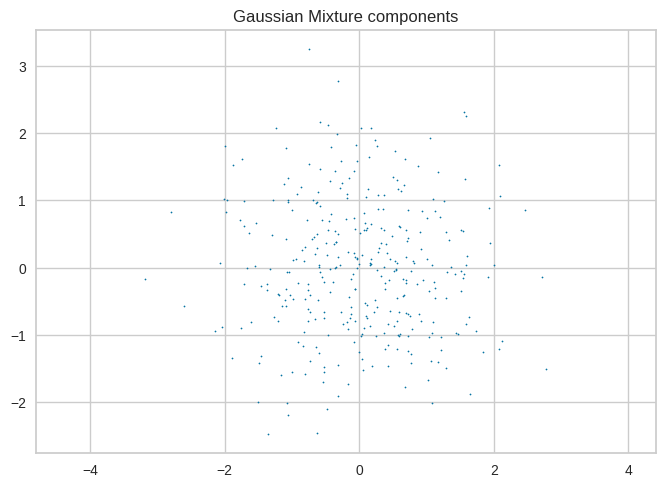

     Number of components Type of covariance     BIC score
0                      10          spherical  1.690426e+05
1                      10          spherical  1.689801e+05
2                      11          spherical  1.720809e+05
3                      11          spherical  1.719868e+05
4                      12          spherical  1.752865e+05
..                    ...                ...           ...
103                    13               full  1.870146e+07
104                    14               full  4.347485e+07
105                    14               full  1.997437e+07
106                    15               full  4.518943e+07
107                    15               full  2.126878e+07

[108 rows x 3 columns]


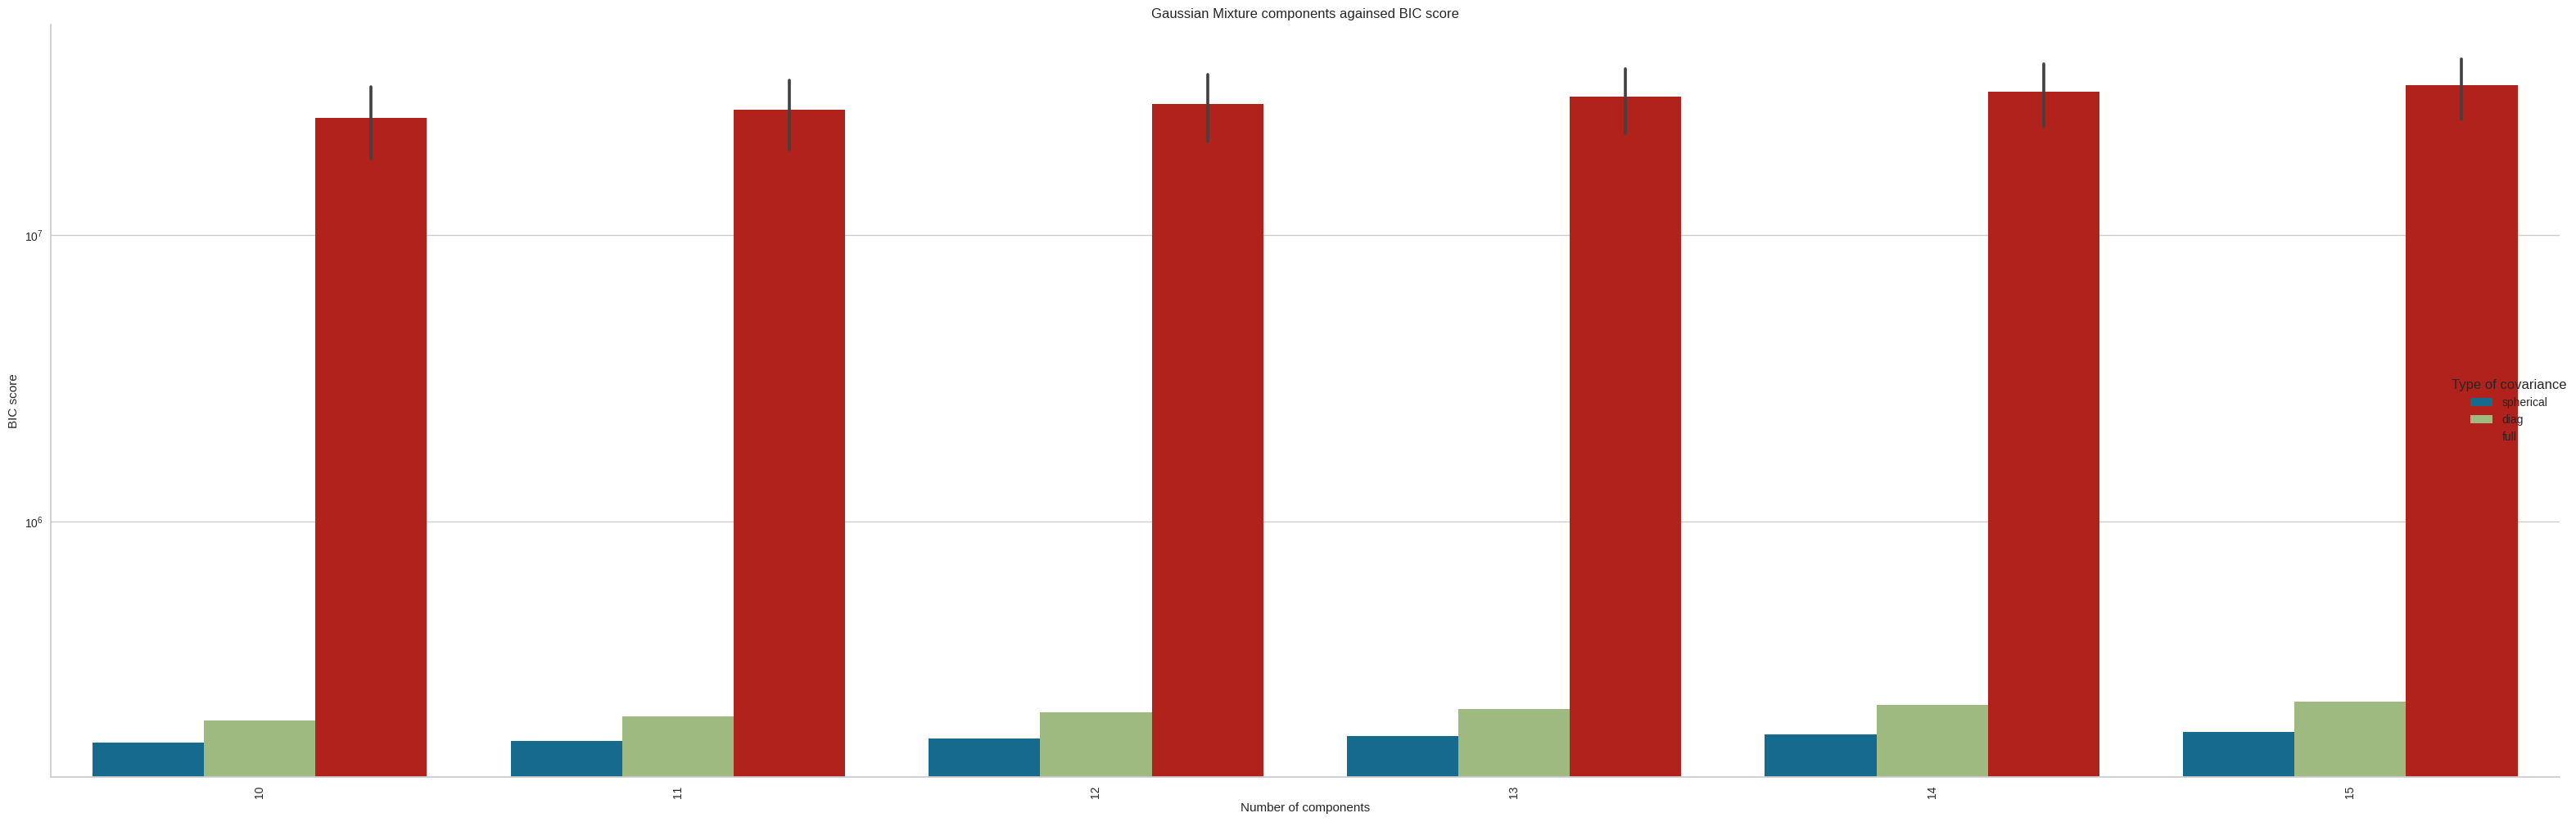

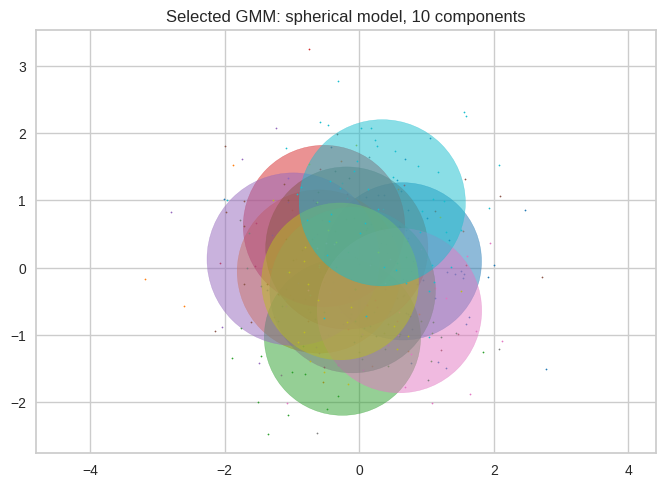

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
def Gaussion_Mixture_Model_for_Clustering(embeddings,clustering_df):
  # trying to find normal distribution of data to cluster by
  #n_clusters = 20

  #embeddings = scaling_embeddings(embeddings)
  embeddings_2d = np.vstack(the_profile_embeddings_array)# converting to a sinbgle 2d array of shape (339,768)
  embeddings_2d = scaling_embeddings(embeddings_2d)



  #gmm = GaussianMixture(n_components=n_clusters, covariance_type='diag', random_state=42)
  #gmm.fit(embeddings_2d)
  gmm = finding_optimal_params(embeddings_2d)

  # Predict cluster labels and probabilities
  cluster_ids = gmm.predict(embeddings_2d) #  pedcit clusetr labels for each point (pofile)
  cluster_probs = gmm.predict_proba(embeddings_2d)# cluster is saying i think theis profie belongs t me this much

  #trying to evaluate clsueting perfomance
  evaluating_GMM(embeddings_2d,gmm)


  clustering_df['cluster'] = cluster_ids #  adding the labels in teh sam erow as that prfile
  clustering_df['cluster_probs'] = cluster_probs.tolist() # adding teh rpbs of each difernt clsuer to taht row
  plotting_best_model(gmm,embeddings_2d)
  df_save_path = "/content/drive/MyDrive/Dissertation/clustering_results.csv"
  clustering_df.to_csv(df_save_path, index=False)
  return clustering_df
clustering_df = Gaussion_Mixture_Model_for_Clustering(the_profile_embeddings_array,clustering_df)

In [ ]:
print(clustering_df)

##Loading and training SBERT

Loading SBERT mdoel to train

In [ ]:
#!pip install sentence-transformers


from torch.utils.data import DataLoader

# importing SBERT model
SBERT = SentenceTransformer("all-MiniLM-L6-v2")

Loading in clusterd df

In [ ]:
df_save_path = "/content/drive/MyDrive/Dissertation/clustering_results.csv"
clustering_df = pd.read_csv(df_save_path)

Building pairs for SBERT

In [ ]:
'''
Here we are greting posativea nd negative apirs out of the te clustered samples(profles). A posativev pair consists of two samples in the same
GMM cluster. And  negaive two different. Tese pairs are then used as lbles in training.
'''
def creating_pairs(clustering_df):
  from itertools import combinations
  import random

  positive_pairs = []

  # Group by cluster and make all combos within each group
  for cluster_id, group in clustering_df.groupby('cluster'):
      texts = group['data'].tolist()
      for sent1, sent2 in combinations(texts, 2):  # all pairs in that cluster
          positive_pairs.append({
              'sentence1': sent1,
              'sentence2': sent2,
              'label': 1.0 #  meaning posative
          })


  # Get all texts with their cluster
  cluster_groups = clustering_df.groupby('cluster')['data'].apply(list).to_dict()
  clusters = list(cluster_groups.keys())

  negative_pairs = []

  # Create negative pairs by randomly sampling across clusters
  while len(negative_pairs) < len(positive_pairs):  # match the count of positives
      c1, c2 = random.sample(clusters, 2)  # pick 2 different clusters
      s1 = random.choice(cluster_groups[c1])
      s2 = random.choice(cluster_groups[c2])

      negative_pairs.append({
          'sentence1': s1,
          'sentence2': s2,
          'label': -1
      })
      # re shuffling the list so doesnt stat with alll postaive
  all_pairs = positive_pairs + negative_pairs
  random.shuffle(all_pairs)


  #inputs structuered for SBERT with label column
  train_examples = [
      InputExample(texts=[item['sentence1'], item['sentence2']], label=item['label'])
      for item in all_pairs
  ]
  return train_examples
train_examples = creating_pairs(clustering_df)

Data Loader to push posative and negative paired in cosine smiliarity loss

In [ ]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

Loss function for trainign

In [ ]:
train_loss = losses.CosineSimilarityLoss(model=SBERT)

In [ ]:
# #!pip install datasets
# from datasets import Dataset
# SBERT.fit(
#     train_objectives=[(train_dataloader, train_loss)],
#     epochs=3,
#     warmup_steps=10,
#     show_progress_bar=True
# )
# #saving the pre-trained weights of te sbert model
# SBERT.save("/content/drive/MyDrive/Dissertation/SBERT_finetuned")

#Generting Embeddings using SBERT

In [ ]:
model_path = "/content/drive/MyDrive/Dissertation/SBERT_finetuned"
SBERT = SentenceTransformer(model_path)

In [ ]:
'''
TThis should loop throug a copy of the cleaned dataframe and replace each profile with the emdbeedidng of that goven profile.
'''

def creating_SBERT_embeddings(embedding_df,SBERT):


    # embeds each column
  def embed_text(text):
    if pd.isna(text):
        return np.zeros((768,))
    return SBERT.encode(str(text))

  embedding_df['data'] = embedding_df['data'].apply(embed_text)  # Replace strings with embeddings

  # Save separate embeddings DataFrame to picl file
  embedding_df.to_pickle("/content/drive/MyDrive/Dissertation/SBERT_embeddings.pkl")


  # saving the pre-trained weights of te bert model toa pkl file for later embeddings
  SBERT.save("/content/drive/MyDrive/Dissertation/SBERT_finetuned")



  return embedding_df
creating_SBERT_embeddings(embedding_df,SBERT)

,data
Profile Sophie Alex Fitness profile number 1,"[0.08666013, -0.0830821, -0.072142094, 0.02065..."
Profile Oliver Mansfield profile number 2,"[-0.0018072732, 0.16347513, 0.03296249, 0.0144..."
Profile Emma Jane Taylor profile number 3,"[-0.004720144, -0.114761844, 0.002933868, -0.0..."
Profile Fit With Alf profile number 4,"[0.059227023, -0.05776826, -0.062207352, 0.028..."
Profile Phil Rebbetts Personal Training profile number 5,"[0.10002837, -0.10587112, -0.07565834, -0.0357..."
...,...
Profile CTT - Carl Tracey Training profile number 6036,"[-0.092183396, -0.047756735, 0.062430497, 0.07..."
Profile Quality Lifestyles profile number 6189,"[-0.023286724, -0.08952034, 0.035948493, -0.05..."
Profile cre8-u profile number 7570,"[-0.10477752, -0.050662823, 0.05895272, 0.0769..."
Profile Aman Johal profile number 8012,"[0.009192909, 0.09848813, -0.0162941, -0.04018..."
